In [1]:
using Distributed
addprocs(25)
@everywhere include("1_timed_resk.jl")

In [5]:
A, tim = @timed rangeexp_ray_inf(200,300,25;x_max_burnin=5,x_max_exp=500,data_to_generate="F",capacity=100,prolif_rate=2,mut_rate=0.05,migr_rate=0.05,sel_coef=0.005,weightfitn=false,condsel=true,fixed_mate=true,multiproc=true)
tim

Running 25 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26] processes


15.6028397

In [23]:
A["fitn"][:,:,22]

500×500 Matrix{Float32}:
   1.0    0.999847    0.999639  …    1.00651     1.00525     1.00567
   1.0    0.99983     0.999756       1.00283     1.00133     1.00128
   1.0    0.999706    0.999563       0.998387    0.999813    0.999506
   1.0    0.999788    0.999764       1.00283     1.00229     1.00163
   1.0    0.999845    0.999515       1.0011      1.0033      1.0033
 NaN    NaN         NaN         …    1.00472     1.0053      1.00598
 NaN    NaN         NaN              1.00258     1.00026     1.00165
 NaN    NaN         NaN              0.983772    0.983488    0.986828
 NaN    NaN         NaN              0.996983    0.995507    0.996137
 NaN    NaN         NaN              0.996517    0.997187    0.99793
   ⋮                            ⋱                          
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN           

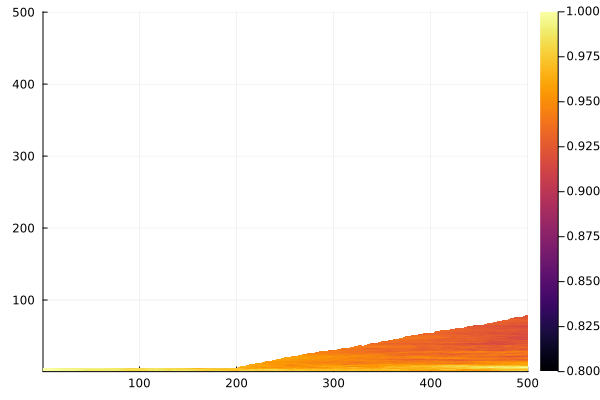

In [15]:
using Plots
heatmap(A["fitn"][:,:,21],clim=(0.8,1.0))

In [5]:
@show A["fitn"][:,end,1]

(A["fitn"])[:, end, 1] = Float32[1.0049111, 1.0031276, 1.0067309, 1.0084358, 1.0104117, 1.0084698, 0.9955332, 0.99266803, 0.9945496, 0.9889173, 0.9865552, 0.986765, 0.9846171, 0.9751167, 0.96225196, 0.96779287, 0.9701219, 0.97598284, 0.97292006, 0.9674113, 0.96315885, 0.9702031, 0.96507555, 0.96414316, 0.96114695, 0.9552527, 0.9605193, 0.96138316, 0.95641357, 0.95892125, 0.95586634, 0.9489535, 0.9493486, 0.94604623, 0.94738346, 0.9413892, 0.9420695, 0.93954575, 0.93988466, 0.94346845, 0.9374066, 0.93386936, 0.9308707, 0.93638474, 0.94287187, 0.94172615, 0.9383801, 0.93588084, 0.9340709, 0.9365782, 0.9358941, 0.94273734, 0.94109, 0.94353265, 0.93880963, 0.9323282, 0.9198504, 0.9214709, 0.9289268, 0.92436785, 0.9247366, 0.921821, 0.9223769, 0.9215162, 0.9256383, 0.929578, 0.93291014, 0.92859197, 0.93001837, 0.932116, 0.9316257, 0.93140376, 0.93347174, 0.93415815, 0.93776774, 0.93875706, 0.9386586, 0.93902093, 0.9393392, 0.93892485, 0.9388335, 0.93218356, NaN, NaN, NaN, NaN, NaN, NaN, NaN

500-element Vector{Float32}:
   1.0049111
   1.0031276
   1.0067309
   1.0084358
   1.0104117
   1.0084698
   0.9955332
   0.99266803
   0.9945496
   0.9889173
   ⋮
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN
 NaN

In [13]:
[findlast(x -> !isnan(x), A["fitn"][:,:,j]) for j in 1:25]

25-element Vector{CartesianIndex{2}}:
 CartesianIndex(82, 500)
 CartesianIndex(77, 500)
 CartesianIndex(78, 500)
 CartesianIndex(83, 500)
 CartesianIndex(84, 500)
 CartesianIndex(79, 500)
 CartesianIndex(79, 500)
 CartesianIndex(82, 500)
 CartesianIndex(78, 500)
 CartesianIndex(78, 500)
 ⋮
 CartesianIndex(83, 500)
 CartesianIndex(80, 500)
 CartesianIndex(77, 500)
 CartesianIndex(78, 500)
 CartesianIndex(83, 500)
 CartesianIndex(82, 500)
 CartesianIndex(79, 500)
 CartesianIndex(89, 500)
 CartesianIndex(85, 500)

In [14]:
indicess = [findlast(x -> !isnan(x), A["fitn"][:,:,j]) for j in 1:25]
last_valid_index = mean(ci.I[1] for ci in indicess)

80.36

In [6]:
using Statistics

avg = mapslices(x -> mean(skipmissing(x)), A["fitn"]; dims=3)[:,:,1]

500×500 Matrix{Float32}:
   1.0    0.999794    0.999544  …    0.990226    0.989966    0.989637
   1.0    0.999815    0.999618       0.988507    0.988564    0.988906
   1.0    0.999823    0.999632       0.989894    0.989978    0.98997
   1.0    0.99979     0.999579       0.989957    0.990458    0.990554
   1.0    0.999817    0.999659       0.990338    0.990284    0.990556
 NaN    NaN         NaN         …    0.987287    0.987234    0.987303
 NaN    NaN         NaN              0.986331    0.986294    0.986761
 NaN    NaN         NaN              0.983207    0.983549    0.983528
 NaN    NaN         NaN              0.981717    0.981721    0.981317
 NaN    NaN         NaN              0.977975    0.978054    0.978383
   ⋮                            ⋱                          
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN    

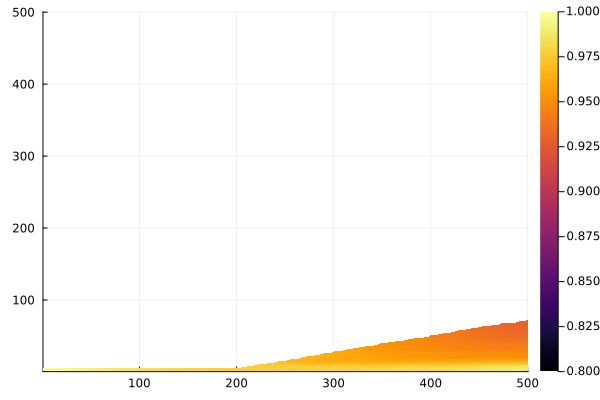

In [8]:
using Plots
heatmap(avg,clim=(0.8,1.0))

In [9]:
avg[findlast(x -> !isnan(x), avg)]

0.92875975f0

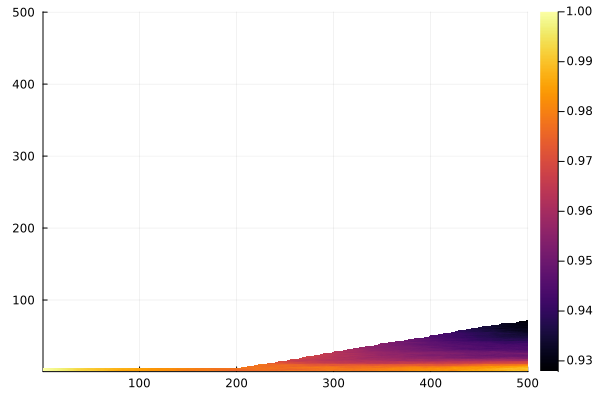

In [10]:
heatmap(avg)

---

In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_resk.jl")

In [4]:
A, tim = @timed rangeexp_ray_inf(200,500,10;x_max_burnin=5,x_max_exp=500,data_to_generate="FP",capacity=100,prolif_rate=2,mut_rate=0.05,migr_rate=0.05,sel_coef=0.005,weightfitn=false,condsel=true,fixed_mate=true,multiproc=true)
tim

Running 10 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] processes


16.4384224

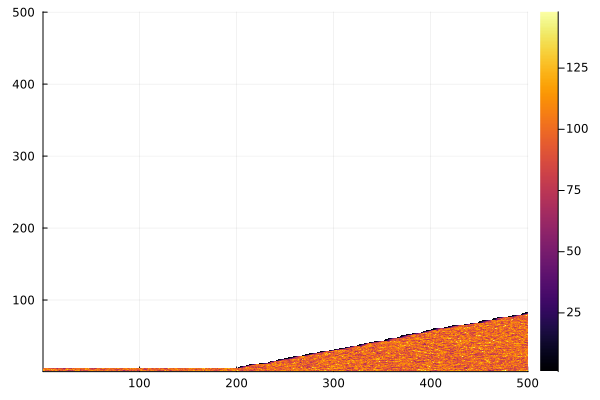

In [4]:
using Plots
heatmap(A["pops"][:,:,1])

---

In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_resk_opt.jl")

In [1]:
include("1_timed_resk_opt.jl")

rangeexp_ray_inf (generic function with 4 methods)

In [3]:
A, tim = @timed rangeexp_ray_inf(200,500,10)
tim

Running 10 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11] processes


15.0141159

In [4]:
A.pops

500×12500 Matrix{Float32}:
 112.0  107.0  107.0   98.0   94.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
  77.0   87.0  103.0   93.0   90.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 103.0   94.0   97.0  110.0  122.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
  94.0   91.0   94.0   85.0   98.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
  96.0  103.0  113.0  106.0  102.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   5.0   13.0   21.0   34.0   41.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    4.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   ⋮                                ⋱            ⋮                   
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0    0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
   0.0    0.0    0.0    0.0

---

In [1]:
using Distributed
n_re = 25
addprocs(n_re)
@everywhere include("1_timed_resk_opt2.jl")

In [2]:
# Run replicates
results = Vector{NamedTuple{(:pops, :fitness), Tuple{Array{typ_float}, Array{typ_float}}}}(undef, n_re)
A, tim = @timed pmap(rangeexp_ray_inf, 1:n_re)
wo = workers()
println("Running $n_re replicates on $wo processes")
tim

Running 25 replicates on [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26] processes


19.7371342

In [4]:
A[1].fitness

500×500 Matrix{Float32}:
 0.986744  0.987435  0.98696   0.986184  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.9858    0.987075  0.987162  0.98688      0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.98615   0.985438  0.986428  0.987495     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.990989  0.991995  0.990816  0.990294     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.98827   0.989099  0.987679  0.988117     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.985087  0.986521  0.984105  0.988667  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0       0.0       0.0       0.988408     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0       0.0       0.0       0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0       0.0       0.0       0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0       0.0       0.0       0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                                       ⋱            ⋮                   
 0.0       0.0       0.0       0.0          0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0       0.0       0.0       0.0        

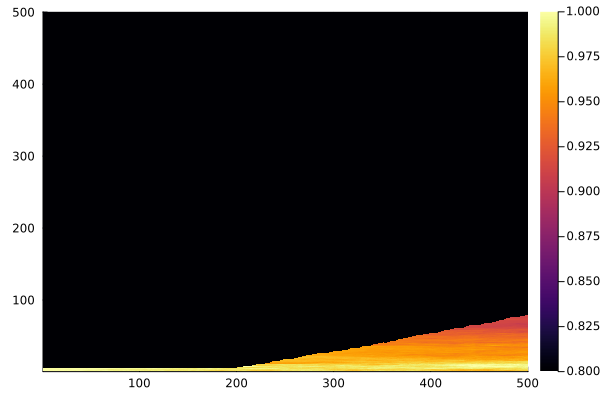

In [4]:
using Plots
heatmap(A[6].fitness,clim=(0.8,1.0))